<a href="https://colab.research.google.com/github/rgdeekshith/FIFA-World-Cup-Match-Prediction-using-Model-Selection/blob/main/FIFA_World_Cup_Match_Outcome_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FIFA World Cup Match Outcome Prediction

### Section 1: Data loading, feature engineering, and multinomial logistic regression baseline (H/D/A).

In [49]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# Make plots appear inside the notebook
%matplotlib inline

# Set a basic style for plots
sns.set(style="whitegrid")

In [50]:
csv_path = "/content/fifa_worldcup_1930_2022.csv"

# Try reading with default encoding; if it errors, we'll switch to latin1
try:
    df = pd.read_csv(csv_path)
except UnicodeDecodeError:
    df = pd.read_csv(csv_path, encoding="latin1")

df.head()

,Key Id,Tournament Id,tournament Name,Match Id,Match Name,Stage Name,Group Name,Group Stage,Knockout Stage,Replayed,...,Away Team Score Margin,Extra Time,Penalty Shootout,Score Penalties,Home Team Score Penalties,Away Team Score Penalties,Result,Home Team Win,Away Team Win,Draw
0,1,WC-1930,1930 FIFA World Cup,M-1930-01,France v Mexico,group stage,Group 1,1,0,0,...,-3,0,0,0-0,0,0,home team win,1,0,0
1,2,WC-1930,1930 FIFA World Cup,M-1930-02,United States v Belgium,group stage,Group 4,1,0,0,...,-3,0,0,0-0,0,0,home team win,1,0,0
2,3,WC-1930,1930 FIFA World Cup,M-1930-03,Yugoslavia v Brazil,group stage,Group 2,1,0,0,...,-1,0,0,0-0,0,0,home team win,1,0,0
3,4,WC-1930,1930 FIFA World Cup,M-1930-04,Romania v Peru,group stage,Group 3,1,0,0,...,-2,0,0,0-0,0,0,home team win,1,0,0
4,5,WC-1930,1930 FIFA World Cup,M-1930-05,Argentina v France,group stage,Group 1,1,0,0,...,-1,0,0,0-0,0,0,home team win,1,0,0


In [51]:
df.columns.isna()

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False])

In [52]:
df[["Result", "Home Team Win", "Away Team Win", "Draw"]].head()

,Result,Home Team Win,Away Team Win,Draw
0,home team win,1,0,0
1,home team win,1,0,0
2,home team win,1,0,0
3,home team win,1,0,0
4,home team win,1,0,0


In [53]:
def get_result_label(row):
    if row["Home Team Win"] == 1:
        return "H"  # Home win
    elif row["Away Team Win"] == 1:
        return "A"  # Away win
    elif row["Draw"] == 1:
        return "D"  # Draw
    else:
        return None  # Unexpected case

df["ResultLabel"] = df.apply(get_result_label, axis=1)

df[["Result", "Home Team Win", "Away Team Win", "Draw", "ResultLabel"]].head(10)

,Result,Home Team Win,Away Team Win,Draw,ResultLabel
0,home team win,1,0,0,H
1,home team win,1,0,0,H
2,home team win,1,0,0,H
3,home team win,1,0,0,H
4,home team win,1,0,0,H
5,home team win,1,0,0,H
6,home team win,1,0,0,H
7,home team win,1,0,0,H
8,home team win,1,0,0,H
9,home team win,1,0,0,H


In [54]:
df["ResultLabel"].value_counts()
df["ResultLabel"].value_counts(normalize=True)

,proportion
ResultLabel,
H,0.565353
A,0.248963
D,0.185685


In [55]:
# Convert Match Date to datetime
df["Match Date"] = pd.to_datetime(df["Match Date"], errors="coerce")

# Extract Year from Match Date
df["Year"] = df["Match Date"].dt.year

# Check a few rows to verify
df[["Match Date", "Year", "Home Team Name", "Away Team Name", "Country Name"]].head()

,Match Date,Year,Home Team Name,Away Team Name,Country Name
0,1930-07-13,1930,France,Mexico,Uruguay
1,1930-07-13,1930,United States,Belgium,Uruguay
2,1930-07-14,1930,Yugoslavia,Brazil,Uruguay
3,1930-07-14,1930,Romania,Peru,Uruguay
4,1930-07-15,1930,Argentina,France,Uruguay


In [56]:
# Create HomeIsHost feature: 1 if home team country equals host country, else 0
df["HomeIsHost"] = (df["Home Team Name"] == df["Country Name"]).astype(int)

df[["Home Team Name", "Country Name", "HomeIsHost"]].head(10)

,Home Team Name,Country Name,HomeIsHost
0,France,Uruguay,0
1,United States,Uruguay,0
2,Yugoslavia,Uruguay,0
3,Romania,Uruguay,0
4,Argentina,Uruguay,0
5,Chile,Uruguay,0
6,Yugoslavia,Uruguay,0
7,United States,Uruguay,0
8,Uruguay,Uruguay,1
9,Chile,Uruguay,0


In [57]:
feature_cols = [
    "Home Team Name",
    "Away Team Name",
    "Group Stage",
    "Knockout Stage",
    "Country Name",
    "Year",
    "HomeIsHost",
]

In [58]:
X = df[feature_cols].copy()
y = df["ResultLabel"].copy()

In [59]:
categorical_cols = ["Home Team Name", "Away Team Name", "Country Name"]
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=False)

X_encoded.head()
X_encoded.shape

(964, 188)

In [60]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)
X_train.shape, X_test.shape, X_encoded.shape

((771, 188), (193, 188), (964, 188))

In [61]:
from sklearn.linear_model import LogisticRegression

In [62]:
log_reg = LogisticRegression(
    multi_class="multinomial",  # use multinomial (softmax) version for multi-class
    solver="lbfgs",             # optimization algorithm suitable for multinomial
    max_iter=1000,              # allow enough iterations for convergence
    C=1.0                       # regularization strength (inverse of lambda)
)

In [63]:
log_reg.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000, multi_class='multinomial')

In [64]:
# Predict the most likely class for each test match
y_pred = log_reg.predict(X_test)

# Predict full probability distribution over classes for each test match
y_proba = log_reg.predict_proba(X_test)

# Show first 5 predicted labels and probabilities
y_pred[:5], y_proba[:5]

(array(['H', 'D', 'H', 'D', 'H'], dtype=object),
 array([[0.1461318 , 0.22416129, 0.62970691],
        [0.05969142, 0.6549124 , 0.28539618],
        [0.29377761, 0.25756475, 0.44865765],
        [0.10122522, 0.75512121, 0.14365357],
        [0.22278936, 0.02532605, 0.75188459]]))

In [65]:
# Accuracy: fraction of correct predictions
acc = accuracy_score(y_test, y_pred)

# Macro F1: average F1 across classes (H, D, A)
macro_f1 = f1_score(y_test, y_pred, average="macro")

acc, macro_f1

(0.5284974093264249, 0.38483761638103614)

In [66]:
cm = confusion_matrix(y_test, y_pred, labels=["H", "D", "A"])
cm

array([[85, 10, 14],
       [20,  5, 11],
       [30,  6, 12]])

In [67]:
print(classification_report(y_test, y_pred, labels=["H", "D", "A"]))

              precision    recall  f1-score   support

           H       0.63      0.78      0.70       109
           D       0.24      0.14      0.18        36
           A       0.32      0.25      0.28        48

    accuracy                           0.53       193
   macro avg       0.40      0.39      0.38       193
weighted avg       0.48      0.53      0.50       193



### Logistic Regression (Multinomial) – Baseline Results

- Accuracy (test): ~0.53  
- Macro F1 (test): ~0.38  
- Lowest F1 class: Draw ("D")

## Section 2: Random Forest Classifier

In [68]:
from sklearn.ensemble import RandomForestClassifier

In [69]:
rf_clf = RandomForestClassifier(
    n_estimators=200,      # number of trees in the forest
    max_depth=None,       # allow trees to grow fully (other params will stop them)
    min_samples_split=2,  # a node must have at least 2 samples to be split
    min_samples_leaf=1,   # a leaf must have at least 1 sample
    max_features="sqrt",  # at each split, consider sqrt(total_features) randomly chosen features
    random_state=42,      # reproducibility
    n_jobs=-1             # use all CPU cores available
)

In [70]:
rf_clf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [71]:
# Predict class labels on the test set
y_pred_rf = rf_clf.predict(X_test)

# Predict class probabilities on the test set
y_proba_rf = rf_clf.predict_proba(X_test)

# Compute accuracy and macro F1
acc_rf = accuracy_score(y_test, y_pred_rf)
macro_f1_rf = f1_score(y_test, y_pred_rf, average="macro")

acc_rf, macro_f1_rf

(0.538860103626943, 0.4261661186213616)

In [72]:
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=["H", "D", "A"])
cm_rf

array([[81,  9, 19],
       [20,  7,  9],
       [28,  4, 16]])

In [73]:
print(classification_report(y_test, y_pred_rf, labels=["H", "D", "A"]))

              precision    recall  f1-score   support

           H       0.63      0.74      0.68       109
           D       0.35      0.19      0.25        36
           A       0.36      0.33      0.35        48

    accuracy                           0.54       193
   macro avg       0.45      0.42      0.43       193
weighted avg       0.51      0.54      0.52       193



In [74]:
print("=== Logistic Regression (Multinomial) ===")
print(classification_report(y_test, y_pred, labels=["H", "D", "A"]))

print("\n=== Random Forest ===")
print(classification_report(y_test, y_pred_rf, labels=["H", "D", "A"]))

=== Logistic Regression (Multinomial) ===
              precision    recall  f1-score   support

           H       0.63      0.78      0.70       109
           D       0.24      0.14      0.18        36
           A       0.32      0.25      0.28        48

    accuracy                           0.53       193
   macro avg       0.40      0.39      0.38       193
weighted avg       0.48      0.53      0.50       193


=== Random Forest ===
              precision    recall  f1-score   support

           H       0.63      0.74      0.68       109
           D       0.35      0.19      0.25        36
           A       0.36      0.33      0.35        48

    accuracy                           0.54       193
   macro avg       0.45      0.42      0.43       193
weighted avg       0.51      0.54      0.52       193



<Figure size 400x400 with 0 Axes>

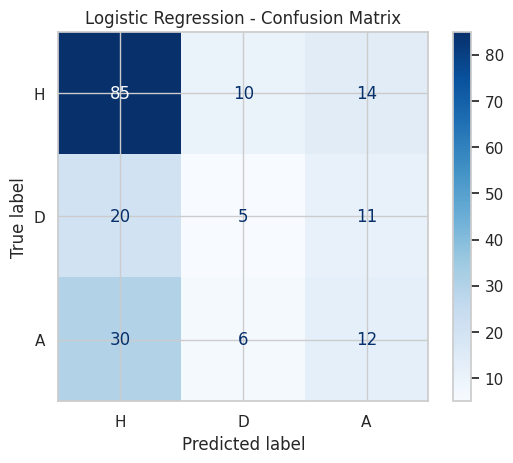

<Figure size 400x400 with 0 Axes>

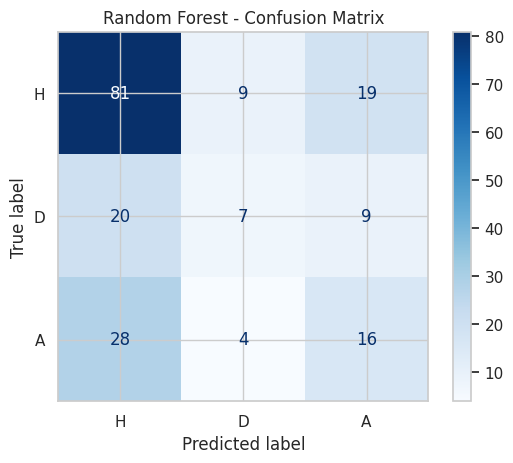

In [75]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

labels = ["H", "D", "A"]

# Confusion matrix for Logistic Regression
cm_log = confusion_matrix(y_test, y_pred, labels=labels)
disp_log = ConfusionMatrixDisplay(confusion_matrix=cm_log, display_labels=labels)

plt.figure(figsize=(4, 4))
disp_log.plot(cmap="Blues", values_format="d")
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

# Confusion matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=labels)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=labels)

plt.figure(figsize=(4, 4))
disp_rf.plot(cmap="Blues", values_format="d")
plt.title("Random Forest - Confusion Matrix")
plt.show()

Get feature importances as a table

In [76]:
import pandas as pd

importances = pd.Series(
    rf_clf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

importances.head(20)

,0
Year,0.098132
Home Team Name_Brazil,0.017636
Home Team Name_Argentina,0.017535
Group Stage,0.017342
Knockout Stage,0.016666
Away Team Name_Spain,0.014227
Away Team Name_Netherlands,0.013643
Home Team Name_Spain,0.013336
Away Team Name_Italy,0.013288
Home Team Name_Italy,0.013132


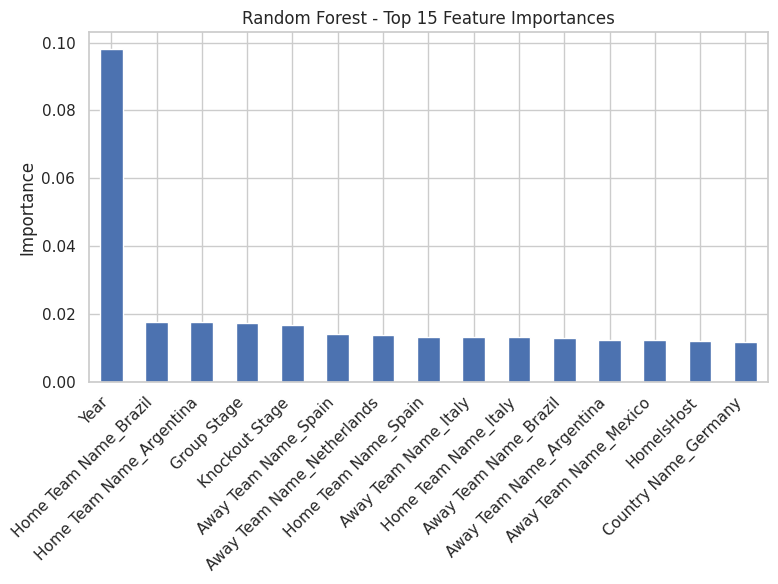

In [77]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
importances.head(15).plot(kind="bar")
plt.title("Random Forest - Top 15 Feature Importances")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Testing to see if "Year" feature is actually important for this model**

Plan 1 – Retrain RF without Year and save results

In [78]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score

# 1. Drop 'Year' from features
X_train_no_year = X_train.drop(columns=["Year"])
X_test_no_year  = X_test.drop(columns=["Year"])

# 2. Retrain Random Forest (same basic settings as before)
rf_no_year = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_no_year.fit(X_train_no_year, y_train)

# 3. Predictions
y_pred_rf_no_year = rf_no_year.predict(X_test_no_year)

# 4. Compare classification reports
print("=== Random Forest (original, with Year) ===")
print(classification_report(y_test, y_pred_rf, labels=["H", "D", "A"]))

print("\n=== Random Forest (no Year) ===")
print(classification_report(y_test, y_pred_rf_no_year, labels=["H", "D", "A"]))

# 5. Quick global comparison
print("\nOriginal RF - acc:", accuracy_score(y_test, y_pred_rf))
print("Original RF - macro F1:", f1_score(y_test, y_pred_rf, average="macro"))

print("\nRF no Year - acc:", accuracy_score(y_test, y_pred_rf_no_year))
print("RF no Year - macro F1:", f1_score(y_test, y_pred_rf_no_year, average="macro"))

=== Random Forest (original, with Year) ===
              precision    recall  f1-score   support

           H       0.63      0.74      0.68       109
           D       0.35      0.19      0.25        36
           A       0.36      0.33      0.35        48

    accuracy                           0.54       193
   macro avg       0.45      0.42      0.43       193
weighted avg       0.51      0.54      0.52       193


=== Random Forest (no Year) ===
              precision    recall  f1-score   support

           H       0.60      0.74      0.66       109
           D       0.40      0.17      0.24        36
           A       0.35      0.31      0.33        48

    accuracy                           0.53       193
   macro avg       0.45      0.41      0.41       193
weighted avg       0.50      0.53      0.50       193


Original RF - acc: 0.538860103626943
Original RF - macro F1: 0.4261661186213616

RF no Year - acc: 0.5284974093264249
RF no Year - macro F1: 0.40963295784896553

**Plan 2 – Permutation importance for Year on original model
We keep the original RF (with Year), and only measure how important Year is.**

In [79]:
from sklearn.inspection import permutation_importance

# Run permutation importance on the original RF model
result = permutation_importance(
    rf_clf,
    X_test,          # use test (or validation) set
    y_test,
    n_repeats=30,    # number of shuffles per feature
    random_state=42,
    n_jobs=-1
)

importances_mean = result.importances_mean
importances_std  = result.importances_std

# Put into a Series for easy lookup
perm_importances = pd.Series(importances_mean, index=X_test.columns)

# Show Year importance
print("Permutation importance for 'Year':")
print("mean:", perm_importances["Year"])
print("std :", importances_std[list(X_test.columns).index("Year")])

# Optional: show top 10 permutation importances
print("\nTop 10 features by permutation importance:")
print(perm_importances.sort_values(ascending=False).head(10))

Permutation importance for 'Year':
mean: 0.013471502590673598
std : 0.01941450154942507

Top 10 features by permutation importance:
Year                                  0.013472
Home Team Name_England                0.007427
Away Team Name_Brazil                 0.007427
Home Team Name_Saudi Arabia           0.006390
Home Team Name_Republic of Ireland    0.005872
Home Team Name_France                 0.005699
Away Team Name_Czechoslovakia         0.005527
Away Team Name_Croatia                0.005354
Country Name_France                   0.005354
Away Team Name_Hungary                0.005181
dtype: float64


**Plan 3 – If “no Year” model looks better, inspect and tweak it**

3a. Inspect trees and depth

In [80]:
# Number of trees
print("Number of trees:", len(rf_no_year.estimators_))

# Depth of each tree
tree_depths = [estimator.tree_.max_depth for estimator in rf_no_year.estimators_]
print("Min depth:", min(tree_depths))
print("Max depth:", max(tree_depths))
print("Average depth:", sum(tree_depths) / len(tree_depths))

Number of trees: 100
Min depth: 62
Max depth: 102
Average depth: 81.79


3b. Class balance of predictions (H/D/A)

In [81]:
import numpy as np

unique, counts = np.unique(y_pred_rf_no_year, return_counts=True)
pred_dist = dict(zip(unique, counts))
print("Prediction counts (RF no Year):", pred_dist)

Prediction counts (RF no Year): {'A': np.int64(43), 'D': np.int64(15), 'H': np.int64(135)}


3c. Try a small hyperparameter tweak – min_samples_leaf

In [82]:
rf_no_year_ms5 = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    min_samples_leaf=5
)
rf_no_year_ms5.fit(X_train_no_year, y_train)

y_pred_rf_no_year_ms5 = rf_no_year_ms5.predict(X_test_no_year)

print("=== RF no Year, min_samples_leaf=1 (baseline) ===")
print(classification_report(y_test, y_pred_rf_no_year, labels=["H", "D", "A"]))

print("\n=== RF no Year, min_samples_leaf=5 ===")
print(classification_report(y_test, y_pred_rf_no_year_ms5, labels=["H", "D", "A"]))

print("\nBaseline RF no Year - macro F1:",
      f1_score(y_test, y_pred_rf_no_year, average="macro"))
print("RF no Year (min_samples_leaf=5) - macro F1:",
      f1_score(y_test, y_pred_rf_no_year_ms5, average="macro"))

=== RF no Year, min_samples_leaf=1 (baseline) ===
              precision    recall  f1-score   support

           H       0.60      0.74      0.66       109
           D       0.40      0.17      0.24        36
           A       0.35      0.31      0.33        48

    accuracy                           0.53       193
   macro avg       0.45      0.41      0.41       193
weighted avg       0.50      0.53      0.50       193


=== RF no Year, min_samples_leaf=5 ===
              precision    recall  f1-score   support

           H       0.57      0.96      0.71       109
           D       0.00      0.00      0.00        36
           A       0.14      0.02      0.04        48

    accuracy                           0.55       193
   macro avg       0.24      0.33      0.25       193
weighted avg       0.36      0.55      0.41       193


Baseline RF no Year - macro F1: 0.40963295784896553
RF no Year (min_samples_leaf=5) - macro F1: 0.2502164502164502


In [85]:
from sklearn.metrics import accuracy_score, f1_score, classification_report
import numpy as np
import pandas as pd

def summarize_all_plans():
    print("=== PLAN 1: Remove 'Year' ===")
    acc_orig  = accuracy_score(y_test, y_pred_rf)
    f1_orig   = f1_score(y_test, y_pred_rf, average="macro")
    acc_no_y  = accuracy_score(y_test, y_pred_rf_no_year)
    f1_no_y   = f1_score(y_test, y_pred_rf_no_year, average="macro")

    print(f"Original RF   - acc: {acc_orig:.3f}, macro F1: {f1_orig:.3f}")
    print(f"RF without Year - acc: {acc_no_y:.3f}, macro F1: {f1_no_y:.3f}")

    if f1_no_y > f1_orig + 0.01:
        print("Interpretation: Removing 'Year' clearly improved macro F1.")
    elif f1_no_y < f1_orig - 0.01:
        print("Interpretation: Removing 'Year' clearly hurt macro F1.")
    else:
        print("Interpretation: Removing 'Year' made little or no difference to macro F1.")

    print("\nClass-wise F1 (original RF vs RF no Year):")
    report_orig  = classification_report(y_test, y_pred_rf,  labels=["H","D","A"], output_dict=True)
    report_no_y  = classification_report(y_test, y_pred_rf_no_year, labels=["H","D","A"], output_dict=True)
    for cls in ["H","D","A"]:
        f1_o = report_orig[cls]["f1-score"]
        f1_n = report_no_y[cls]["f1-score"]
        print(f"  {cls}: original {f1_o:.2f} -> no Year {f1_n:.2f}")

    print("\n=== PLAN 2: Permutation importance for 'Year' ===")
    # assumes you ran permutation_importance and stored result
    importances_mean = result.importances_mean
    importances_std  = result.importances_std
    perm_importances = pd.Series(importances_mean, index=X_test.columns)

    year_mean = perm_importances["Year"]
    year_std  = importances_std[list(X_test.columns).index("Year")]
    print(f"'Year' permutation importance - mean drop in score: {year_mean:.4f} ± {year_std:.4f}")

    top10 = perm_importances.sort_values(ascending=False).head(10)
    print("\nTop 10 permutation importances:")
    print(top10)

    rank_year = perm_importances.rank(ascending=False)["Year"]
    print(f"\nRank position of 'Year' among all features (1 = most important): {int(rank_year)}")

    print("\nInterpretation:")
    if year_mean <= 0.001:
        print("  'Year' has almost no impact when shuffled -> model hardly relies on it.")
    elif year_mean < 0.01:
        print("  'Year' has a small effect -> weak/secondary feature.")
    else:
        print("  'Year' has a noticeable effect -> model really uses it.")

    print("\n=== PLAN 3: min_samples_leaf tweak on RF no Year ===")
    f1_no_y_base = f1_no_y
    f1_no_y_ms5  = f1_score(y_test, y_pred_rf_no_year_ms5, average="macro")
    print(f"RF no Year (baseline)       - macro F1: {f1_no_y_base:.3f}")
    print(f"RF no Year (min_samples_leaf=5) - macro F1: {f1_no_y_ms5:.3f}")

    rep_ms5 = classification_report(y_test, y_pred_rf_no_year_ms5,
                                    labels=["H","D","A"], output_dict=True)
    print("\nF1 for class D (draw):")
    print(f"  baseline RF no Year       : {report_no_y['D']['f1-score']:.2f}")
    print(f"  RF no Year, ms_leaf=5     : {rep_ms5['D']['f1-score']:.2f}")

    if f1_no_y_ms5 > f1_no_y_base + 0.01:
        print("Interpretation: Increasing min_samples_leaf improved generalization.")
    elif f1_no_y_ms5 < f1_no_y_base - 0.01:
        print("Interpretation: Increasing min_samples_leaf hurt macro F1 (too simple).")
    else:
        print("Interpretation: Changing min_samples_leaf had little effect overall.")

# Run this once everything else has been computed
summarize_all_plans()

=== PLAN 1: Remove 'Year' ===
Original RF   - acc: 0.539, macro F1: 0.426
RF without Year - acc: 0.528, macro F1: 0.410
Interpretation: Removing 'Year' clearly hurt macro F1.

Class-wise F1 (original RF vs RF no Year):
  H: original 0.68 -> no Year 0.66
  D: original 0.25 -> no Year 0.24
  A: original 0.35 -> no Year 0.33

=== PLAN 2: Permutation importance for 'Year' ===
'Year' permutation importance - mean drop in score: 0.0135 ± 0.0194

Top 10 permutation importances:
Year                                  0.013472
Home Team Name_England                0.007427
Away Team Name_Brazil                 0.007427
Home Team Name_Saudi Arabia           0.006390
Home Team Name_Republic of Ireland    0.005872
Home Team Name_France                 0.005699
Away Team Name_Czechoslovakia         0.005527
Away Team Name_Croatia                0.005354
Country Name_France                   0.005354
Away Team Name_Hungary                0.005181
dtype: float64

Rank position of 'Year' among all feat

Reusing the base Random Forest model using joblib

In [88]:
# 1. Install/import joblib
# In most recent scikit‑learn setups, joblib is already installed.

import joblib

In [87]:
'''
2. Save your trained Random Forest
Assuming:

Your final RF model (with Year) is called rf_clf.

You want to save it as rf_worldcup.joblib in the current folder.
'''

import joblib

filename = "rf_worldcup.joblib"  # choose any name you like
joblib.dump(rf_clf, filename)

print(f"Model saved to {filename}")

Model saved to rf_worldcup.joblib


If the model is huge, you can optionally compress:

joblib.dump(rf_clf, filename, compress=3)  # 0–9, higher = more compression

3. Load the model later and use it
In a future session/notebook/script:

import joblib

filename = "rf_worldcup.joblib"
loaded_rf = joblib.load(filename)

Now you can use loaded_rf just like rf_clf

y_pred_loaded = loaded_rf.predict(X_test)

## Section 3:

1.	GradientBoostingClassifier (from sklearn) - Pure boosting, good starting point, slower but simple API.

2.	XGBoost / LightGBM / CatBoost - More powerful gradient boosting libraries, often top on tabular data, but extra dependencies and more hyperparameters.


**Gradient Boost**

In [89]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score

gb_clf = GradientBoostingClassifier(
    n_estimators=100,   # number of trees (boosting stages)
    learning_rate=0.1, # how much each tree corrects previous errors
    max_depth=3,       # depth of each individual tree
    random_state=42
)

gb_clf.fit(X_train, y_train)

y_pred_gb = gb_clf.predict(X_test)